### HANDLE MISSING VALUES
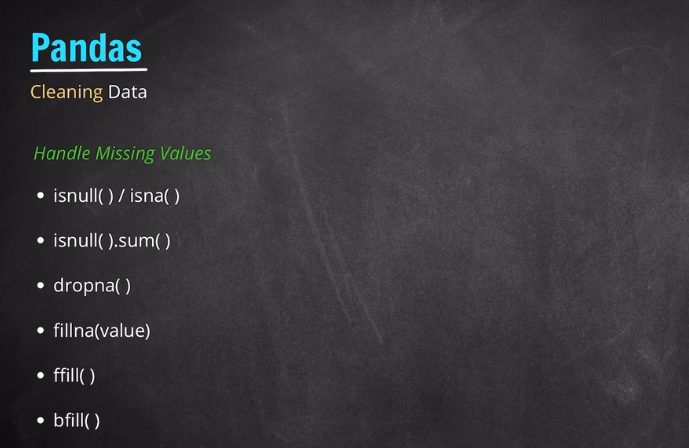

In [2]:
import pandas as pd

In [15]:
df=pd.read_csv("raw_data.csv")
df.isnull()
df.isnull().sum()
df.dropna() #row drop wherever null value
df.dropna(axis=1) #col drop wherever null value
# df.fillna(0) #all missing values will be replaced by 0

# we want to replace missing age values with mean age
#first we create a copy of the original DF. 
cleaned_data=df.copy()
# calculate the mean
age_mean=cleaned_data["age"].mean()
# fill missing values with mean
cleaned_data["age"]=cleaned_data["age"].fillna(age_mean)

cleaned_data

#ffill() forward fill--- coming up to down --- fills the last (above) valid value in the empty cell
#bfill() backward fill --- down to up --- fills the last (below) valid value in the empty cell

,id,name,age,country,gender,income
0,1,John Doe,29.00,USA,Male,55000.0
1,1,John Doe,29.00,USA,Male,55000.0
2,2,Jane Smith,32.75,Canada,Female,62000.0
3,3,Alex,32.75,USA,Unknown,47000.0
4,4,Maria Garcia,34.00,Spain,Female,NaN
5,5,Li Wei,27.00,China,Male,51000.0
6,6,NaN,45.00,India,Female,73000.0
7,7,Ahmed Khan,38.00,NaN,Male,68000.0
8,8,Rachel Lee,29.00,USA,Female,62000.0
9,9,Carlos Ruiz,32.75,Mexico,Male,45000.0


### Deduplicate values

In [23]:
df.duplicated() # whole duplicate rows
df.duplicated(["country"]) #duplicate countries
df[["country","gender"]].duplicated() # checking where both country and gender are same

#create copy
df2=df.copy()
df.drop_duplicates(inplace=True) # use (inplace=True) if you want to change the original data. BUT make a copy of the original data before making changes to the original data so that you can go back to it if you ever need.
# now original got changed. we can recover the original using copy
df=df2

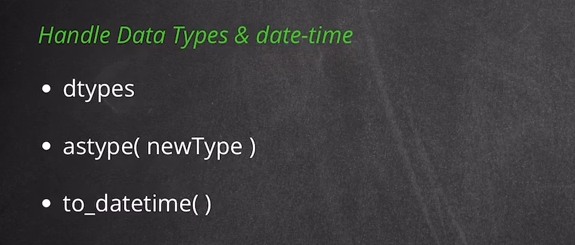

In [49]:
# handling different data types

#create a copy
df2=df.copy()
#replace missing values with zero because Nan cannot be typecasted to int64
df2=df2.fillna(0)

#converting age to int64 from float64
df2=df2["age"].astype("int64").copy()
print(df2.dtypes)

#datetime

# string to datetime
date_str=pd.Series([pd.to_datetime("2026-12-31")])
type(date_str.dtypes)

int64


numpy.dtypes.DateTime64DType

### Strings

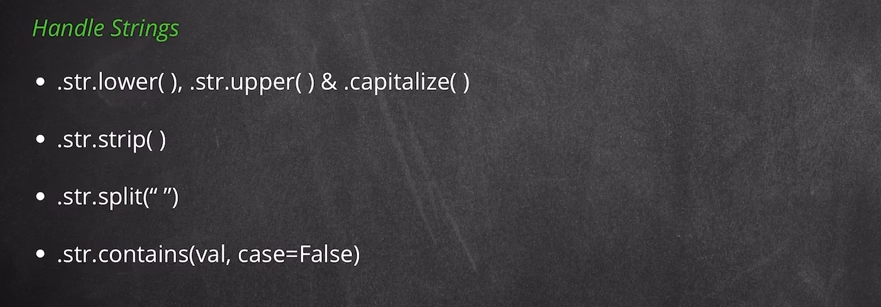

In [55]:
df["gender"].str.lower()
df["gender"].str.upper()
df["gender"].str.capitalize()
df["gender"].str.strip()
df["name"].str.split(" ")
df["country"].str.contains("US") #check if US exists in coutries in df
df["country"].str.contains("us", case=False) # ignore the case


0      True
2     False
3      True
4     False
5     False
6     False
7       NaN
8      True
9     False
10     True
Name: country, dtype: object